In [ ]:
!pip -q install pillow scikit-image opencv-python-headless

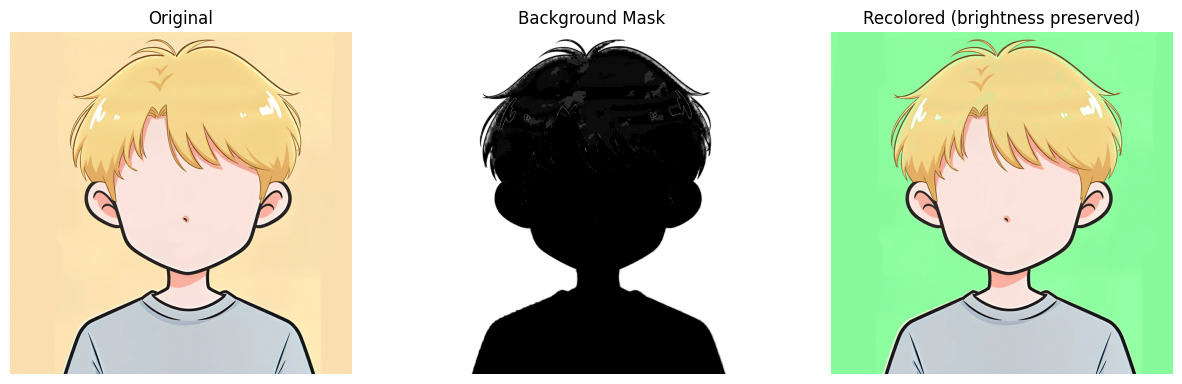

Saved: recolored_background.png


In [ ]:
import numpy as np
from PIL import Image
from skimage import color
import matplotlib.pyplot as plt
import cv2

# =========================
# 1) Load image
# =========================

IMG_PATH = "/content/blonde.png"

img_rgb = np.array(Image.open(IMG_PATH).convert("RGB")) / 255.0  # [0,1], float
H, W, _ = img_rgb.shape

# =========================
# 2) Parameters
# =========================
# Target color 
TARGET_HEX = "#32a852"   # background color choice

PATCH = 5         # average of a 5x5 patch at the top-left to sample background color
AB_THRESH = 6.0   # inside this a/b distance → definitely background (tighter)
AB_SOFT  = 14.0   # beyond this a/b distance → definitely NOT background (softer edge)

# Small morphology to bridge tiny gaps between hair waves
MORPH_KERNEL = 3  # set to 0/1 to disable; 3-5 strengthens background fill through hair

# =========================
# 3) Build mask in CIELAB space (using only a,b → brightness invariant)
# =========================
lab = color.rgb2lab(img_rgb)
L, A, B = lab[...,0], lab[...,1], lab[...,2]

# Sample background chroma from top-left PATCH x PATCH region
bg_patch = lab[:PATCH, :PATCH, :]
a0 = float(bg_patch[...,1].mean())
b0 = float(bg_patch[...,2].mean())

# a/b distance only
ab_dist = np.sqrt((A - a0)**2 + (B - b0)**2)

# Soft mask: 1.0=background, 0.0=foreground
m = 1.0 - np.clip((ab_dist - AB_THRESH) / max(1e-6, (AB_SOFT - AB_THRESH)), 0.0, 1.0)

m_u8 = (m * 255).astype(np.uint8)
if MORPH_KERNEL and MORPH_KERNEL >= 2:
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL, MORPH_KERNEL))
    m_u8 = cv2.morphologyEx(m_u8, cv2.MORPH_CLOSE, k, iterations=1)  # closes tiny gaps
m_u8 = cv2.GaussianBlur(m_u8, (0,0), 0.8)  # soft edges for anti-aliasing
m = m_u8.astype(np.float32) / 255.0

# =========================
# 4) Recolor background while preserving brightness (L channel)
#     -> keep L from original; replace only a,b toward target color
# =========================
def hex_to_rgb01(h):
    h = h.lstrip("#")
    return np.array([int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)]) / 255.0

target_rgb = hex_to_rgb01(TARGET_HEX)[None,None,:]       # shape (1,1,3)
target_lab = color.rgb2lab(target_rgb)                   # to Lab
a_t, b_t = float(target_lab[0,0,1]), float(target_lab[0,0,2])

A_new = A*(1.0 - m) + a_t*m
B_new = B*(1.0 - m) + b_t*m
lab_new = np.stack([L, A_new, B_new], axis=-1)

img_out = np.clip(color.lab2rgb(lab_new), 0, 1)

# =========================
# 5) Show & Save
# =========================
fig, ax = plt.subplots(1,3, figsize=(15,6))
ax[0].imshow(img_rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(m, cmap="gray"); ax[1].set_title("Background Mask"); ax[1].axis("off")
ax[2].imshow(img_out); ax[2].set_title("Recolored (brightness preserved)"); ax[2].axis("off")
plt.show()

out_path = "recolored_background.png"
Image.fromarray((img_out*255).astype(np.uint8)).save(out_path)
print("Saved:", out_path)